# Validacion de QC

Esta libreta ejecuta el pipeline de reduccion y carga el resumen de calidad para inspeccion manual.

In [8]:
from pathlib import Path
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import reduction.io as reduction_io
import reduction.calibration as reduction_calibration
import reduction.pipeline as reduction_pipeline

importlib.reload(reduction_io)
importlib.reload(reduction_calibration)
importlib.reload(reduction_pipeline)

ReductionPaths = reduction_pipeline.ReductionPaths
run_reduction_pipeline = reduction_pipeline.run_reduction_pipeline

In [10]:
paths = ReductionPaths(
    raw_dir=PROJECT_ROOT / 'data' / 'raw',
    output_dir=PROJECT_ROOT / 'data' / 'reduced',
)
result_table = run_reduction_pipeline(paths)
qc_df = result_table.to_pandas()
qc_df.head(25)


,file,filter,quality_flag,mean,median,std,min_value,max_value,saturation_fraction,bad_pixel_fraction
0,qatar1b-001.fit,NO_FILTER,ok,61.071054,55.618749,219.525218,-3466.823897,42955.962428,0.000000,0.006785
1,qatar1b-002.fit,NO_FILTER,ok,85.926012,78.563008,303.409609,-4859.514634,65648.458815,0.000002,0.001352
2,qatar1b-003.fit,NO_FILTER,ok,86.024681,78.686695,294.678190,-4677.676479,65454.402838,0.000002,0.001281
3,qatar1b-004.fit,NO_FILTER,ok,87.120357,79.710404,324.658424,-4359.713672,65648.458815,0.000006,0.001227
4,qatar1b-005.fit,NO_FILTER,ok,86.819778,79.360976,329.075983,-3788.802818,65348.835843,0.000007,0.001194
5,qatar1b-006.fit,NO_FILTER,ok,87.034672,79.615354,316.550571,-3559.219449,65648.458815,0.000002,0.001216
6,qatar1b-007.fit,NO_FILTER,ok,87.223727,79.839578,337.643439,-3296.112845,65648.458815,0.000007,0.001108
7,qatar1b-008.fit,NO_FILTER,ok,86.871345,79.470697,321.508854,-3433.253353,65648.458815,0.000006,0.001157
8,qatar1b-009.fit,NO_FILTER,ok,86.555193,79.139482,307.682632,-3596.806107,65305.378633,0.000002,0.001154
9,qatar1b-010.fit,NO_FILTER,ok,86.759544,79.317074,335.019208,-3416.999663,65454.402838,0.000007,0.001137


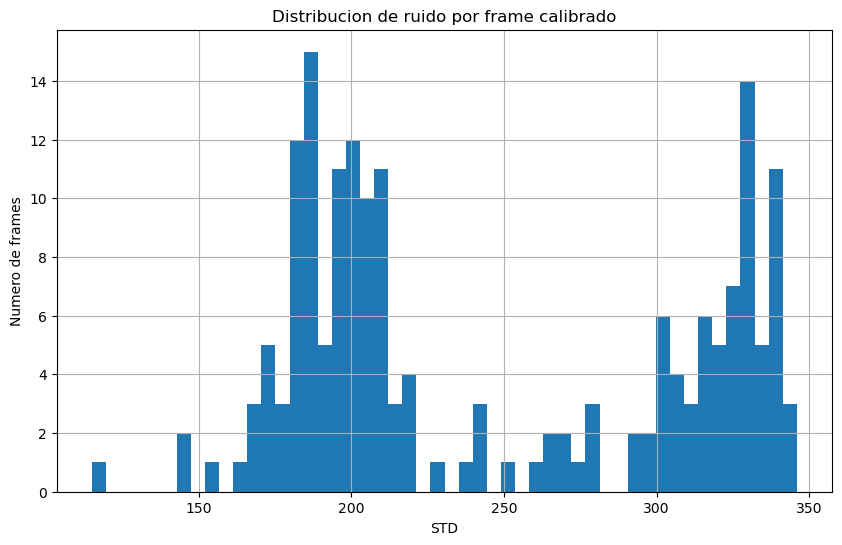

In [15]:
qc_df['std'].hist(bins=50, figsize=(10, 6))
plt.title('Distribucion de ruido por frame calibrado')
plt.xlabel('STD')
plt.ylabel('Numero de frames')
plt.show()

In [12]:
qc_df['quality_flag'].value_counts()

quality_flag
ok    182
Name: count, dtype: int64